# Stage 3a — Multiplicative LoRA Fine-Tuning
## Model: `meta-llama/Llama-3.2-3B-Instruct` | Dataset: CB1 (6-Class Cyberbullying)
**Framework:** Generalised LoRA — Wf = W(I + UV) + AB  
**This stage:** Multiplicative only — **Wf = W(I + UV)**  
**Seed:** 42 | **Split:** 75/25 stratified | **Primary metric:** Macro F1 | **Secondary:** MCC

---

## README — Before Step 1: Stage 2 vs Stage 3 Conceptual Comparison

Read this before running any code. It explains exactly what changes between Standard LoRA (Stage 2) and Multiplicative LoRA (Stage 3), and why.

### Formula comparison

| Aspect | Stage 2 — Standard LoRA | Stage 3 — Multiplicative LoRA |
|---|---|---|
| **Formula** | `Wf = W + AB` | `Wf = W(I + UV)` |
| **Adapter type** | Additive — ΔW = AB is added to W | Multiplicative — W is right-multiplied by (I + UV) |
| **Adapter shape** | A ∈ ℝᵐˣʳ, B ∈ ℝʳˣⁿ (rectangular) | U ∈ ℝⁿˣʳ, V ∈ ℝʳˣⁿ; square adapter I+UV ∈ ℝⁿˣⁿ |
| **Initialisation** | B = 0 → AB = 0 at start → Wf = W | V = 0 → UV = 0 at start → I+UV = I → Wf = W |
| **Effect on column space** | Adds new directions to W's column space — can increase effective rank beyond rank(W) | Acts within W's existing column space — cannot add directions beyond W's column space |
| **Rank theory (Prop. 1)** | rank(W + AB) ≤ rank(W) + r (rank can grow) | rank(W(I+UV)) ≤ rank(W); if I+UV invertible → rank(W(I+UV)) = rank(W) exactly |
| **Eff. rank prediction** | Constant across r ✓ (confirmed Stage 2) | Hypothesis: still constant — **this is the Stage 3 research question** |
| **L2 component (AB)** | AB is the adapter (L2 ≠ 0) | L2 = 0 — multiplicative only |
| **Regularisation character** | Freely shifts the weight matrix in any direction | Constrained to re-route W's existing computation |
| **lora_alpha convention** | = lora_rank → scaling = 1.0 | = lora_rank → scaling = 1.0 (same) |
| **PEFT implementation** | `LoraConfig` + `get_peft_model()` | Custom `MultiplicativeLoRALayer` — PEFT has no built-in support |
| **`AutoModelForSequenceClassification`** | Used directly (PEFT wraps it) | Used directly — custom adapter injected post-load |
| **Key research question** | Does eff. rank of Wf stay constant across r? → YES, confirmed | Does multiplicative adaptation change rank dynamics vs additive? |
| **Stage 1 ceiling (CB1)** | Phi-4 FS Macro F1 = 0.5757 (demolished by +0.28) | Same ceiling — must also beat Stage 2 best: Gemma-2-9B F1 = 0.9010 |

### Why PEFT's LoraConfig is not used here

PEFT's `LoraConfig` hardcodes the additive formula `Wf = W + AB`. There is no built-in support for `Wf = W(I + UV)`. Instead, we:
1. Load `AutoModelForSequenceClassification` in 4-bit NF4 (same as Stage 2)
2. Call `prepare_model_for_kbit_training()` (same as Stage 2)
3. Replace each target linear layer with a `MultiplicativeLoRALayer` wrapper that stores trainable U and V, freezes W, and computes `y = W·x + W·(U·(V·x))` on the forward pass

### Effective rank — what changes

- **Stage 2:** SVD on Wf = W + ΔW where ΔW = B@A (reconstructed via `bnb_F.dequantize_4bit`)
- **Stage 3:** SVD on Wf = W + W@(UV) (equivalent to W(I+UV), reconstructed via same dequantisation)
- Both measure eff. rank of **the full adapted weight matrix**, NOT of the adapter alone

### Protocol (non-negotiable — carries from Stage 2)

- **Step 12:** r=16 (default). **Step 13:** RANK_SWEEP = [4, 8, 32] — r=16 NOT repeated, merged from Step 12
- CB1: MAX_LENGTH=256 | Batch=16 | lora_alpha = lora_rank | EVAL_STEPS=200
- Training time printed after every `trainer.train()` in seconds and hours
- `train_runtime_s` saved to CSV every run
- Stability plot: 2 panels only (loss + val metrics) — identical to Stage 2
- No EarlyStoppingCallback — removed (meaningless with 1 epoch)


---
## Step 1: Install Required Libraries

**Purpose**: Install all Python packages with pinned versions compatible with Colab's environment.

**Why so many pins?**  
Colab's pre-installed stack (torch, torchvision, cudf, etc.) has tight inter-dependency constraints.  
Three classes of conflicts affect this notebook:

| Problem | Symptom | Fix |
|---|---|---|
| `numpy>=2.1` | `ImportError: cannot import name '_center'` at torch import | Pin `numpy<2.1` |
| `pandas>=3.0` | Breaks cudf, db-dtypes, gradio | Pin `pandas<3.0` |
| `torchvision` mismatch | `ImportError: cannot import name 'VideoReader' from torchvision.io` during datasets formatting | Pin `torchvision==0.20.1` to match Colab's torch 2.5.x |

**After running this cell: Runtime → Restart Runtime, then run from Step 2 onwards.**  
Do NOT re-run Step 1 after restart.


In [1]:
# ── Install with pinned versions — compatible with Colab's environment ──────────
# Do NOT use -U (upgrade-all) — it upgrades numpy/pandas/torchvision and breaks imports.

!pip install -q \
    "transformers>=4.47.0" \
    "peft>=0.14.0" \
    "bitsandbytes>=0.45.0" \
    "accelerate>=1.2.0" \
    "datasets>=3.0.0" \
    "numpy<2.1" \
    "pandas<3.0" \
    "torchvision==0.20.1" \
    "scikit-learn" \
    tqdm matplotlib seaborn

# ── IMPORTANT: Restart runtime after this cell ────────────────────────────────
# Runtime → Restart Runtime  (Ctrl+M .)
# After restart: run from Step 2 onwards — do NOT re-run this cell.
print("✓ Installation complete.")
print()
print("=" * 60)
print("  ACTION REQUIRED: Restart the Colab runtime now.")
print("  Runtime → Restart Runtime  (or Ctrl+M .)")
print("  After restart: run from Step 2 onwards.")
print("  Do NOT re-run Step 1 after restart.")
print("=" * 60)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 145.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 151.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 115.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## Step 2: Import Libraries and Initial Setup

**Purpose**: Import all modules, set random seeds, load HF token, mount Drive.  
**Identical to Stage 2** — only the stage label in print statements differs.  
HF token loaded from Colab Secrets (key: `HF_TOKEN`) — same as Stage 2.


In [1]:
import os
import random
import collections
import re
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    matthews_corrcoef,
)

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    TrainerCallback,
)
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model
# NOTE: LoraConfig + get_peft_model are used in Stage 3 as a PEFT registration shell.
# Transformers Trainer (>=4.47) checks _is_peft_model() and rejects purely quantised models.
# We register the model as a PEFT model first (so the check passes), then replace
# the PEFT LoRA layers with our custom MultiplicativeLoRALayer.

import bitsandbytes.functional as bnb_F

from google.colab import drive, userdata

# ── Reproducibility ──────────────────────────────────────────────────────────
def set_all_seeds(seed: int = 42):
    """Fix all random seeds for fully reproducible training."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)

# ── HuggingFace token ────────────────────────────────────────────────────────
def load_hf_token() -> str:
    token = userdata.get('HF_TOKEN')
    if token is None:
        raise ValueError("HF_TOKEN not found. Add it via Colab Secrets (key icon in sidebar).")
    os.environ['HF_TOKEN'] = token
    print("✓ HuggingFace token loaded.")
    return token

HF_TOKEN = load_hf_token()

# ── Mount Google Drive ───────────────────────────────────────────────────────
drive.mount('/content/drive')
print("✓ Google Drive mounted.")

# ── GPU check ────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ All random seeds fixed to 42.
✓ HuggingFace token loaded.
Mounted at /content/drive
✓ Google Drive mounted.
✓ Device: cuda
  GPU: NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---
## Step 3: Global Configuration

**Purpose**: All hyperparameters and settings in one place.  
**Changes from Stage 2:**
- `RANK_SWEEP` now = `[4, 8, 32]` — r=16 is NOT included (run in Step 12, merged in Step 13)
- `OUTPUT_DIR` updated to Stage 3 path
- Formula label updated to `Wf = W(I + UV)`
- Everything else is **identical to Stage 2**


In [2]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION — Stage 3a: Multiplicative LoRA | CB1 | Llama-3.2-3B
# ════════════════════════════════════════════════════════════════════════════

# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_NAME   = "meta-llama/Llama-3.2-3B-Instruct"
NUM_LABELS   = 6
MAX_LENGTH   = 256

# ── LoRA (Multiplicative) ─────────────────────────────────────────────────────
LORA_RANK    = 16           # Default rank for Step 12
LORA_ALPHA   = 16           # Always equals LORA_RANK → scaling = 1.0
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']

# Stage 3 rank sweep: r=16 already run in Step 12 — NOT repeated here
RANK_SWEEP   = [4, 8, 32]   # Step 13 only — r=16 merged from Step 12

# ── Training ──────────────────────────────────────────────────────────────────
NUM_EPOCHS          = 1     # Single epoch — protocol requirement
LEARNING_RATE       = 2e-4
TRAIN_BATCH_SIZE    = 16    # Confirmed safe for Llama-3B on A100 40GB
EVAL_BATCH_SIZE     = 32
WEIGHT_DECAY        = 0.01
EVAL_STEPS          = 200
LOGGING_STEPS       = 50
OUTPUT_DIR          = "/content/drive/MyDrive/Results/CB1_MultiplicativeLoRA_Llama3B"

# ── Dataset & Split ───────────────────────────────────────────────────────────
CB1_PATH             = "/content/drive/MyDrive/Datasets/cb1.csv"
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
VAL_FROM_TRAIN       = 0.10
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

# ── Label mapping ─────────────────────────────────────────────────────────────
# Columns: tweet_text | cyberbullying_type
# Labels: not_cyberbullying, gender, religion, ethnicity, age, other_cyberbullying
LABEL_MAPPING = {
    'not_cyberbullying':   0,
    'gender':              1,
    'religion':            2,
    'ethnicity':           3,
    'age':                 4,
    'other_cyberbullying': 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())

print("✓ Configuration loaded.")
print(f"  Stage    : 3a — Multiplicative LoRA")
print(f"  Formula  : Wf = W(I + UV)   [L2 = 0]")
print(f"  Model    : {MODEL_NAME}")
print(f"  LoRA rank: {LORA_RANK}  |  alpha: {LORA_ALPHA}  |  scaling: {LORA_ALPHA/LORA_RANK:.1f}")
print(f"  Epochs   : {NUM_EPOCHS}")
print(f"  Split    : {int(TRAIN_RATIO*100)}% train+val / {int(TEST_RATIO*100)}% test")
print(f"  Labels ({NUM_LABELS}): {TARGET_NAMES}")
print(f"  Rank sweep (Step 13): {RANK_SWEEP}  [r=16 from Step 12 — not repeated]")
print(f"\n  Stage 2 reference (Llama-3B, best r=32): F1=0.8958 | MCC=0.8874")
print(f"  Stage 2 best overall (Gemma-2-9B r=32)  : F1=0.9010 | MCC=0.8936")
print(f"  Stage 1 ceiling (Phi-4 FS)               : F1=0.5757 | MCC=0.5614")


✓ Configuration loaded.
  Stage    : 3a — Multiplicative LoRA
  Formula  : Wf = W(I + UV)   [L2 = 0]
  Model    : meta-llama/Llama-3.2-3B-Instruct
  LoRA rank: 16  |  alpha: 16  |  scaling: 1.0
  Epochs   : 1
  Split    : 75% train+val / 25% test
  Labels (6): ['not_cyberbullying', 'gender', 'religion', 'ethnicity', 'age', 'other_cyberbullying']
  Rank sweep (Step 13): [4, 8, 32]  [r=16 from Step 12 — not repeated]

  Stage 2 reference (Llama-3B, best r=32): F1=0.8958 | MCC=0.8874
  Stage 2 best overall (Gemma-2-9B r=32)  : F1=0.9010 | MCC=0.8936
  Stage 1 ceiling (Phi-4 FS)               : F1=0.5757 | MCC=0.5614


---
## Step 4: Text Preprocessing

**Purpose**: Define LLM-optimised preprocessing for raw tweet text.  
**Identical to Stage 2** — copied verbatim. The same preprocessing must be applied to
guarantee that the train/test split produces exactly the same samples as Stage 2,
making cross-stage comparisons valid.


In [3]:
def preprocess_text_for_llm(text: str,
                             remove_hashtags: bool = False,
                             remove_emojis: bool = False) -> str:
    """LLM-optimised tweet preprocessing — identical to Stage 2."""
    if not isinstance(text, str):
        return ""

    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags:
        text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis:
        text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3:
        return ""
    return text

# ── Quick sanity check ───────────────────────────────────────────────────────
test_tweet = "RT @user123: Check this out http://example.com !!! @someone is so dumb"
print("Before:", test_tweet)
print("After: ", preprocess_text_for_llm(test_tweet))
print("\n✓ Preprocessing function defined.")


Before: RT @user123: Check this out http://example.com !!! @someone is so dumb
After:  Check this out [URL] ! [USER] is so dumb

✓ Preprocessing function defined.


---
## Step 5: Load and Clean the CB1 Dataset

**Purpose**: Load `cb1.csv`, apply all cleaning steps.  
**Columns**: `tweet_text` | `cyberbullying_type`  
**Identical to Stage 2** — same cleaning pipeline ensures identical post-cleaning dataset,
which is required so that the 75/25 split (seeded at 42) produces the same train/test sets.


In [4]:
print("═" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("═" * 60)

df = pd.read_csv(CB1_PATH)
print(f"\n[1] Raw dataset loaded: {len(df):,} samples")

df = df.rename(columns={'tweet_text': 'text', 'cyberbullying_type': 'label'})
print(f"[2] Columns renamed: {df.columns.tolist()}")

corrupt_mask = df['text'].astype(str).str.strip().isin(
    ['#NAME?', '#REF!', '#VALUE!', '#N/A', 'nan', ''])
n_corrupt = corrupt_mask.sum()
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[3] Removed {n_corrupt} corrupt rows → {len(df):,} remaining")

df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[4] After preprocessing: {len(df):,} remaining")

text_label_counts = df.groupby('text')['label'].nunique()
conflicting_texts = text_label_counts[text_label_counts > 1].index
n_conflicting     = df['text'].isin(conflicting_texts).sum()
df = df[~df['text'].isin(conflicting_texts)].reset_index(drop=True)
print(f"[5] Removed {n_conflicting:,} annotation-conflict rows → {len(df):,} remaining")

before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[6] Removed {before - len(df):,} exact duplicates → {len(df):,} remaining")

before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[7] Removed {before - len(df):,} short texts → {len(df):,} remaining")

unknown_labels = set(df['label'].unique()) - set(LABEL_MAPPING.keys())
assert len(unknown_labels) == 0, f"Unknown labels: {unknown_labels}"

print("\n" + "═" * 60)
print("FINAL CB1 CLASS DISTRIBUTION")
print("═" * 60)
counts = df['label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25} {len(df):>6}")
imbalance = counts.max() / counts.min()
print(f"\n  Imbalance ratio : {imbalance:.2f}×")
print("  Primary metric  : Macro F1  |  Secondary: MCC")


════════════════════════════════════════════════════════════
CB1 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw dataset loaded: 47,692 samples
[2] Columns renamed: ['text', 'label']
[3] Removed 0 corrupt rows → 47,692 remaining
[4] After preprocessing: 46,942 remaining
[5] Removed 3,250 annotation-conflict rows → 43,692 remaining
[6] Removed 358 exact duplicates → 43,334 remaining
[7] Removed 0 short texts → 43,334 remaining

════════════════════════════════════════════════════════════
FINAL CB1 CLASS DISTRIBUTION
════════════════════════════════════════════════════════════
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)
  TOTAL                      43334

  Imbalance ratio : 1.37×
  Primary metric  : Macro F1  |  Secondary:

---
## Step 6: Stratified 75/25 Split with Near-Duplicate Check

**Purpose**: Split dataset into train / val / test.  
**Identical to Stage 2** — same split protocol with seed=42 guarantees the exact same
test set as Stage 2, making cross-stage F1 comparisons valid.

Protocol:
- Primary split: 75% train+val / 25% test (stratified, seed=42)
- Near-duplicate check: TF-IDF cosine @0.90 — near-dups moved from test → train
- Validation carved: 10% of train portion → Trainer's eval_dataset
- Test set: touched exactly once per rank (at Step 12 / Step 13 evaluation)


In [5]:
print("═" * 60)
print("DATASET SPLITTING — Protocol: 75% train / 25% test")
print("═" * 60)

# ── Step 6a: Primary stratified split ────────────────────────────────────────
train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_RATIO,
    random_state=RANDOM_STATE,
    stratify=df['label']
)
print(f"\n[1] Primary split → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
print(f"    ({len(train_val_df)/len(df)*100:.1f}% / {len(test_df)/len(df)*100:.1f}%)")

# ── Step 6b: Near-duplicate leakage check ────────────────────────────────────
print(f"\n[2] Near-duplicate check (threshold: {SIMILARITY_THRESHOLD})...")

all_texts    = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs   = tfidf_matrix[:len(train_val_df)]
test_vecs    = tfidf_matrix[len(train_val_df):]

leaked_indices = []
batch_size     = 500
for start in range(0, len(test_df), batch_size):
    end         = min(start + batch_size, len(test_df))
    batch_sims  = cosine_similarity(test_vecs[start:end], train_vecs)
    max_sims    = batch_sims.max(axis=1)
    leaked_mask = max_sims >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())

print(f"    Found {len(leaked_indices)} near-duplicate test samples")

if leaked_indices:
    leaked_samples = test_df.loc[leaked_indices]
    test_df        = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df   = pd.concat([train_val_df, leaked_samples], ignore_index=True)
    print(f"    Moved to train+val → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df      = test_df.reset_index(drop=True)
    print("    ✓ No near-duplicates found.")

# ── Step 6c: Data leakage assertion ──────────────────────────────────────────
overlap = set(train_val_df['text'].tolist()).intersection(set(test_df['text'].tolist()))
assert len(overlap) == 0, f"DATA LEAKAGE DETECTED: {len(overlap)} overlapping samples!"
print("\n    ✓ Data leakage assertion passed — zero train/test overlap.")

# ── Step 6d: Carve validation set from train portion ─────────────────────────
train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_FROM_TRAIN,
    random_state=RANDOM_STATE,
    stratify=train_val_df['label']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"\n[3] Validation carved → Train: {len(train_df):,} | Val: {len(val_df):,}")

# ── Step 6e: Final statistics ─────────────────────────────────────────────────
print("\n" + "═" * 60)
print("FINAL SPLIT STATISTICS")
print("═" * 60)
for name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    pct = len(split_df) / len(df) * 100
    print(f"\n{name} ({len(split_df):,} samples, {pct:.1f}% of total):")
    for label, count in split_df['label'].value_counts().sort_index().items():
        print(f"  {label:<25} {count:>5}  ({count/len(split_df)*100:.1f}%)")

print(f"\n  ✓ Protocol check: test = {len(test_df)/len(df)*100:.1f}% (target: 25.0%)")


════════════════════════════════════════════════════════════
DATASET SPLITTING — Protocol: 75% train / 25% test
════════════════════════════════════════════════════════════

[1] Primary split → Train+Val: 32,500 | Test: 10,834
    (75.0% / 25.0%)

[2] Near-duplicate check (threshold: 0.9)...
    Found 504 near-duplicate test samples
    Moved to train+val → Train+Val: 33,004 | Test: 10,330

    ✓ Data leakage assertion passed — zero train/test overlap.

[3] Validation carved → Train: 29,703 | Val: 3,301

════════════════════════════════════════════════════════════
FINAL SPLIT STATISTICS
════════════════════════════════════════════════════════════

Train (29,703 samples, 68.5% of total):
  age                        5420  (18.2%)
  ethnicity                  5497  (18.5%)
  gender                     5149  (17.3%)
  not_cyberbullying          4235  (14.3%)
  other_cyberbullying        3995  (13.4%)
  religion                   5407  (18.2%)

Validation (3,301 samples, 7.6% of total):
  

---
## Step 7: Helper Functions — Class Weights

**Purpose**: Compute inverse-frequency class weights for the loss function.  
**Identical to Stage 2** — same function, same call site.


In [6]:
def get_class_weights(df: pd.DataFrame, label_col: str = 'label') -> List[float]:
    """Compute inverse-frequency class weights from training labels."""
    counts  = df[label_col].value_counts()
    total   = len(df)
    n_classes = len(LABEL_MAPPING)
    weights = [total / (n_classes * counts.get(ID2LABEL[i], 1)) for i in range(n_classes)]
    weights_norm = [w / sum(weights) * n_classes for w in weights]
    print("Class weights (inverse-frequency, normalised):")
    for i, (cls, w) in enumerate(zip(TARGET_NAMES, weights_norm)):
        print(f"  [{i}] {cls:<25} {w:.4f}")
    return weights_norm

print("✓ get_class_weights() defined.")


✓ get_class_weights() defined.


---
## Step 8: Effective Rank Computation — Multiplicative LoRA

**Purpose**: Compute effective rank of the full adapted weight **Wf = W(I + UV) = W + W@(UV)**.

**Key change from Stage 2:**  
- Stage 2: SVD on `Wf = W + ΔW` where `ΔW = B @ A`  
- Stage 3: SVD on `Wf = W + W @ (U @ V)` — same principle, different adapter reconstruction

**What stays identical:**
- W is dequantised from 4-bit NF4 via `bnb_F.dequantize_4bit()` (same Bug1 fix as Stage 2)
- SVD threshold: `threshold_ratio = 1e-3` of max singular value
- Reports `avg_eff_rank_Wf` (full weight) and `avg_eff_rank_UV` (adapter only, for reference)
- Measured on target layers only (`q_proj`, `k_proj`, `v_proj`, `o_proj`)

**Research question**: Does `eff_rank(Wf)` remain constant across r ∈ {4, 8, 16, 32}?  
Stage 2 confirmed constant eff. rank for additive LoRA (Proposition 1).  
Stage 3 tests whether this holds for multiplicative LoRA (Proposition 3: if I+UV invertible → constant).


In [7]:
def calculate_effective_rank_multiplicative(model: nn.Module,
                                             threshold_ratio: float = 1e-3) -> Dict[str, float]:
    """
    Compute effective rank of Wf = W(I + UV) = W + W @ (UV).

    Walks the model and finds all MultiplicativeLoRALayer instances.
    Reconstructs Wf by dequantising W from 4-bit NF4 and computing W + W@(UV).
    SVD threshold: 0.1% of max singular value (consistent with Stage 2).

    Returns avg_eff_rank_Wf (full weight), avg_eff_rank_UV (adapter only, reference).
    """
    full_ranks = []
    uv_ranks   = []
    per_layer  = []
    skipped    = 0

    for name, module in model.named_modules():
        if not isinstance(module, MultiplicativeLoRALayer):
            continue
        try:
            # Reconstruct UV from trainable parameters
            U  = module.lora_U.data.float()   # (n × r)
            V  = module.lora_V.data.float()   # (r × n)
            UV = U @ V                         # (n × n)

            # Effective rank of UV alone (reference — analogous to Stage 2's ΔW rank)
            S_uv = torch.linalg.svdvals(UV)
            r_uv = int((S_uv > threshold_ratio * S_uv[0]).sum()) if S_uv[0] > 0 else 0
            uv_ranks.append(r_uv)

            # Dequantise W from 4-bit NF4 (module.inner is the actual Linear4bit)
            weight_obj = module.inner.weight
            if hasattr(weight_obj, 'quant_state'):
                try:
                    W = bnb_F.dequantize_4bit(weight_obj.data, weight_obj.quant_state).float()
                except Exception as e:
                    skipped += 1
                    continue
            else:
                W = weight_obj.data.float()

            # Handle transpose if needed (weight stored as (out, in))
            if W.shape[1] != UV.shape[0]:
                if W.T.shape[1] == UV.shape[0]:
                    W = W.T.contiguous()
                else:
                    skipped += 1
                    continue

            # Wf = W + W @ UV  (equivalent to W(I + UV))
            Wf   = W + W @ UV
            S_Wf = torch.linalg.svdvals(Wf)
            r_Wf = int((S_Wf > threshold_ratio * S_Wf[0]).sum()) if S_Wf[0] > 0 else 0

            full_ranks.append(r_Wf)
            per_layer.append({'layer': name, 'rank_Wf': r_Wf, 'rank_UV': r_uv})

        except Exception as e:
            skipped += 1
            continue

    if skipped > 0:
        print(f"  ℹ {skipped} layers skipped during eff. rank computation")
    if not full_ranks:
        print("  ⚠ No MultiplicativeLoRALayer found — check model structure")

    return {
        "avg_eff_rank_Wf": float(np.mean(full_ranks)) if full_ranks else 0.0,
        "avg_eff_rank_UV": float(np.mean(uv_ranks))   if uv_ranks   else 0.0,
        "layer_count":     len(full_ranks),
        "per_layer_ranks": per_layer,
    }

print("✓ calculate_effective_rank_multiplicative() defined.")
print("  SVD on Wf = W + W@(UV)  — NOT on UV alone.")
print("  Uses module.inner (unwrapped Linear4bit) for dequantisation.")
print("  Consistent with Stage 2 Bug1 fix: eff. rank of full Wf, not adapter.")


✓ calculate_effective_rank_multiplicative() defined.
  SVD on Wf = W + W@(UV)  — NOT on UV alone.
  Uses module.inner (unwrapped Linear4bit) for dequantisation.
  Consistent with Stage 2 Bug1 fix: eff. rank of full Wf, not adapter.


---
## Step 9: Evaluation Metrics

**Purpose**: Define all metric functions used during training and final evaluation.  
**Identical to Stage 2** — `compute_metrics()`, `evaluate_dataset()`, and `make_predictions()`
are copied verbatim. The primary metric is Macro F1; secondary is MCC.


In [8]:
def compute_metrics(eval_pred) -> Dict[str, float]:
    """Called by the Trainer at every eval_steps."""
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    accuracy  = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}


def evaluate_dataset(y_true: List[int],
                     y_pred: List[int],
                     dataset_name: str) -> Dict[str, float]:
    """Full evaluation report: per-class F1, MCC, confusion matrices."""
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")

    accuracy     = accuracy_score(y_true, y_pred)
    macro_f1     = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc          = matthews_corrcoef(y_true, y_pred)

    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY METRIC")

    print(f"\n  Classification Report:")
    report = classification_report(
        y_true, y_pred,
        labels=list(range(NUM_LABELS)),
        target_names=TARGET_NAMES,
        zero_division=0, digits=4
    )
    print(report)

    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix (Counts)\n{dataset_name}', fontsize=12)
    axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
    axes[0].tick_params(axis='x', rotation=45)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Confusion Matrix (Normalised)\n{dataset_name}', fontsize=12)
    axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'accuracy': accuracy, 'macro_f1': macro_f1,
        'weighted_f1': weighted_f1, 'balanced_accuracy': bal_accuracy, 'mcc': mcc,
    }


def make_predictions(model, df_test, tokenizer, batch_size=32):
    """Run batched inference on test DataFrame. Returns df with 'predictions' column."""
    model.eval()
    all_preds = []
    texts     = df_test['text'].tolist()

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        enc = tokenizer(
            batch_texts, padding='max_length', truncation=True,
            max_length=MAX_LENGTH, return_tensors='pt'
        ).to(model.device)
        with torch.no_grad():
            logits = model(**enc).logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds.tolist())

    df_out = df_test.copy()
    df_out['predictions'] = [ID2LABEL[p] if isinstance(df_test['label'].iloc[0], str)
                             else p for p in all_preds]
    # Ensure integer labels for metrics
    if isinstance(df_test['label'].iloc[0], str):
        df_out['label'] = df_out['label'].map(LABEL_MAPPING)
        df_out['predictions'] = df_out['predictions'].map(LABEL_MAPPING)
    return df_out


print("✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.")


✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.


---
## Step 10: Training Stability System + Custom Trainer

**Purpose**: StabilityCallback (2-panel, single-epoch protocol) + class-weighted CustomTrainer.  
**Identical to Stage 2** — copied verbatim. The stability system must be identical across
stages so that the cross-stage comparison in Step 14 is valid.

Includes `plot_cross_stage_stability()` — run after all three stages complete.


In [9]:
import matplotlib.gridspec as gridspec

class StabilityCallback(TrainerCallback):
    """
    2-dimension stability tracking (single-epoch protocol).
    Dimension 1 — Loss stability   : std dev & CV across training steps
    Dimension 2 — Metric stability : std dev of val F1 & MCC across eval checkpoints
    Panels 3 & 4 (grad norm / per-epoch) omitted — uninformative with 1 epoch.
    """
    def __init__(self):
        self.train_losses = []
        self.val_metrics  = collections.defaultdict(list)
        self.val_steps    = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0:
            return
        if 'loss' in logs:
            self.train_losses.append((state.global_step, float(logs['loss'])))

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics:
            return
        self.val_steps.append(state.global_step)
        for key, value in metrics.items():
            self.val_metrics[key.replace('eval_', '')].append(float(value))

    def get_stability_report(self) -> Dict:
        report = {}
        if self.train_losses:
            arr = np.array([l for (_, l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall']  = float(np.std(arr))
            report['loss_cv_overall']   = float(np.std(arr) / np.mean(arr)) if np.mean(arr) > 0 else 0.0
        for metric, values in self.val_metrics.items():
            if len(values) > 1:
                arr = np.array(values)
                report[f'val_{metric}_std']   = float(np.std(arr))
                report[f'val_{metric}_range'] = float(arr.max() - arr.min())
                report[f'val_{metric}_best']  = float(arr.max())
                report[f'val_{metric}_final'] = float(arr[-1])
        loss_cv = report.get('loss_cv_overall', 0.0)
        f1_std  = report.get('val_f1_std', 0.0)
        report['stability_score'] = round((loss_cv * 0.5) + (f1_std * 0.5), 6)
        return report

    def plot_stability_curves(self, stage_label: str = 'Stage 3', save_path: str = None):
        """2-panel: Training loss curve + Validation F1 & MCC."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        if self.train_losses:
            steps  = [s for (s, _) in self.train_losses]
            losses = [l for (_, l) in self.train_losses]
            ax1.plot(steps, losses, color='steelblue', linewidth=0.7, alpha=0.5, label='Step loss')
            window = min(20, len(losses))
            if len(losses) >= window:
                roll = np.convolve(losses, np.ones(window)/window, mode='valid')
                ax1.plot(steps[window-1:], roll, color='navy', linewidth=2.2,
                         label=f'Rolling mean (w={window})')
            ax1.set_title(f'{stage_label}\nTraining Loss Curve', fontsize=12)
            ax1.set_xlabel('Global Step'); ax1.set_ylabel('Cross-Entropy Loss')
            ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

        if self.val_steps:
            ax2_r = ax2.twinx() if 'mcc' in self.val_metrics else None
            if 'f1' in self.val_metrics:
                f1_vals = self.val_metrics['f1']
                ax2.plot(self.val_steps, f1_vals, 'o-', color='forestgreen',
                         linewidth=2, markersize=5, label='Macro F1')
                f1_mean = float(np.mean(f1_vals)); f1_std = float(np.std(f1_vals))
                ax2.axhline(f1_mean, color='forestgreen', linestyle=':', linewidth=1.2, alpha=0.6)
                ax2.fill_between(self.val_steps,
                                 [f1_mean - f1_std]*len(self.val_steps),
                                 [f1_mean + f1_std]*len(self.val_steps),
                                 color='forestgreen', alpha=0.10, label=f'±1 std (={f1_std:.4f})')
                ax2.set_ylabel('Macro F1', color='forestgreen', fontsize=10)
                ax2.tick_params(axis='y', labelcolor='forestgreen')
            if ax2_r is not None and 'mcc' in self.val_metrics:
                ax2_r.plot(self.val_steps, self.val_metrics['mcc'], 's--', color='darkorange',
                           linewidth=2, markersize=5, label='MCC')
                ax2_r.set_ylabel('MCC', color='darkorange', fontsize=10)
                ax2_r.tick_params(axis='y', labelcolor='darkorange')
                lines1, lbl1 = ax2.get_legend_handles_labels()
                lines2, lbl2 = ax2_r.get_legend_handles_labels()
                ax2.legend(lines1+lines2, lbl1+lbl2, fontsize=9, loc='lower right')
            ax2.set_title(f'{stage_label}\nValidation Metrics Across Checkpoints', fontsize=12)
            ax2.set_xlabel('Global Step'); ax2.grid(True, alpha=0.3)

        plt.suptitle(f'Training Stability Analysis — {stage_label}',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'  ✓ Stability plot saved → {save_path}')
        plt.show()


class CustomTrainer(Trainer):
    """Extends Trainer with class-weighted cross-entropy loss — identical to Stage 2."""
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = (
            torch.tensor(class_weights, dtype=torch.float32).to(self.args.device)
            if class_weights is not None else None
        )

    def compute_loss(self, model, inputs, num_items_in_batch=None, return_outputs=False):
        labels  = inputs.pop('labels').long()
        outputs = model(**inputs)
        loss    = nn.functional.cross_entropy(outputs.logits, labels, weight=self.class_weights)
        return (loss, outputs) if return_outputs else loss


def plot_cross_stage_stability(stage_reports: Dict[str, Dict], save_path: str = None):
    """Side-by-side stability comparison across Stages 2, 3, 4. Run after all stages complete."""
    labels  = list(stage_reports.keys())
    n       = len(labels)
    colours = ['#2E75B6', '#2E86AB', '#1B998B', '#F4A261'][:n]
    metrics_map = {
        'Loss Std Dev\n(Overall)':              'loss_std_overall',
        'Loss CV\n(Coeff. of Variation)':       'loss_cv_overall',
        'Val F1 Std Dev\n(Across Checkpoints)': 'val_f1_std',
        'Composite\nStability Score':           'stability_score',
    }
    fig, axes = plt.subplots(1, len(metrics_map), figsize=(5.5 * len(metrics_map), 6))
    for ax, (metric_label, metric_key) in zip(axes, metrics_map.items()):
        values = [stage_reports[lbl].get(metric_key, 0.0) or 0.0 for lbl in labels]
        bars   = ax.bar(range(n), values, color=colours, alpha=0.85,
                        edgecolor='white', linewidth=1.5, width=0.6)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(values + [1e-9]) * 0.03,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xticks(range(n)); ax.set_xticklabels(labels, fontsize=9)
        ax.set_title(metric_label, fontsize=11, fontweight='bold')
        ax.set_ylabel('Value  (lower = more stable)', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
    plt.suptitle(
        'Cross-Stage Training Stability Comparison\n'
        'CB1 — 6-Class Cyberbullying | meta-llama/Llama-3.2-3B-Instruct',
        fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  ✓ Cross-stage stability plot saved → {save_path}')
    plt.show()

print('✓ StabilityCallback (2-panel, single-epoch protocol) defined.')
print('✓ CustomTrainer (class-weighted cross-entropy) defined.')
print('✓ plot_cross_stage_stability() defined.')


✓ StabilityCallback (2-panel, single-epoch protocol) defined.
✓ CustomTrainer (class-weighted cross-entropy) defined.
✓ plot_cross_stage_stability() defined.


---
## Step 11: Multiplicative LoRA Adapter + Training Function

**Purpose**: Define `MultiplicativeLoRALayer` and `run_multiplicative_lora()`.  
**This is the only step that materially differs from Stage 2.**

### Why the PEFT shell strategy?

Transformers Trainer (≥4.47) calls `validate_quantization_for_training()` which checks
`_is_peft_model(model)`. If the model is 4-bit quantised but not wrapped by PEFT, it raises:  
`ValueError: You cannot perform fine-tuning on purely quantised models.`

Since our multiplicative adapter is custom (not a PEFT adapter type), we use a two-step approach:

1. **Register the model as a PEFT model** via `get_peft_model(model, LoraConfig(...))` —
   this sets the internal PEFT flag and satisfies the Trainer check. Standard PEFT additive
   LoRA layers (W + AB) are created at this point.
2. **Replace every PEFT LoraLayer with `MultiplicativeLoRALayer`** — our custom multiplicative
   adapter overwrites the additive ones. The model remains flagged as a PEFT model (flag is on
   the model object, not on individual layers), so the Trainer check still passes.

Net result: the Trainer sees a valid PEFT model; training computes `Wf = W(I + UV)`.

### MultiplicativeLoRALayer

Wraps each frozen 4-bit linear layer with trainable U and V:
- `U ∈ ℝⁿˣʳ` — small Gaussian init (`std=0.01`)  
- `V ∈ ℝʳˣⁿ` — zero init → UV = 0 at start → Wf = W at init (safe)  
- Forward: `y = W·x + W·(U·(V·x))` — efficient: V@x costs O(n·r) before hitting W  
- Scaling: `alpha / rank = 1.0` (always, since `alpha = rank`)  
- Dropout applied to the adapter path only

### Effective rank computation

SVD on the **reconstructed full matrix** Wf = W + W@(UV):  
- W dequantised from 4-bit NF4 via `bnb_F.dequantize_4bit()` (same as Stage 2)  
- UV computed from current U, V parameters  
- Effective rank = singular values above 0.1% of max singular value  
- Measures eff. rank of **Wf**, not of UV — consistent with Stage 2 and Proposition 1


In [10]:
import bitsandbytes as bnb

# ════════════════════════════════════════════════════════════════════════════
# MultiplicativeLoRALayer — custom adapter for Wf = W(I + UV)
# ════════════════════════════════════════════════════════════════════════════

class MultiplicativeLoRALayer(nn.Module):
    """
    Wraps a frozen 4-bit linear layer with a multiplicative LoRA adapter.

    Formula: Wf = W(I + UV)
    Forward: y = W·x + W·(U·(V·x))

    U ∈ ℝ^(n×r) : small Gaussian init (std=0.01)
    V ∈ ℝ^(r×n) : zero init → UV=0 at start → Wf=W at initialisation
    scaling = alpha / rank = 1.0 (always, since alpha = rank)

    Preserves the original layer's interface so PEFT's LoraLayer wrapper
    is replaced cleanly without breaking the model's forward pass.
    """
    def __init__(self, base_layer: nn.Module, rank: int, dropout: float = 0.05, alpha: int = None):
        super().__init__()
        self.base_layer = base_layer
        self.rank       = rank
        self.alpha      = alpha if alpha is not None else rank
        self.scaling    = self.alpha / self.rank   # = 1.0 when alpha == rank

        # Determine in_features (n) from the base layer
        # The base_layer here may be a PEFT LoraLayer wrapping a Linear4bit —
        # we unwrap to get the underlying quantised weight's in_features.
        if hasattr(base_layer, 'base_layer'):
            # PEFT wraps as: LoraLayer → base_layer → actual Linear4bit
            inner = base_layer.base_layer
        else:
            inner = base_layer

        if hasattr(inner, 'in_features'):
            n = inner.in_features
        elif hasattr(inner, 'weight'):
            n = inner.weight.shape[1]
        else:
            raise ValueError(f"Cannot determine in_features from {type(inner)}")
        self.n = n
        self.inner = inner  # keep reference to the actual quantised layer for forward

        # Trainable parameters
        self.lora_U = nn.Parameter(torch.empty(n, rank))   # (n × r)
        self.lora_V = nn.Parameter(torch.zeros(rank, n))   # (r × n) — zero init

        # U: small Gaussian; V: zero → UV=0 at start → Wf=W at init (safe)
        nn.init.normal_(self.lora_U, mean=0.0, std=0.01)

        self.dropout = nn.Dropout(p=dropout) if dropout > 0.0 else nn.Identity()

        # Freeze the inner (quantised) layer
        for param in self.inner.parameters():
            param.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Standard path: W @ x  (through the frozen 4-bit layer)
        base_out = self.inner(x)

        # Multiplicative adapter path: W @ (U @ (V @ x))
        # Step 1: V @ x  →  (..., r)
        # Step 2: U @ result  →  (..., n=in_features)
        # Step 3: W @ result  →  (..., out_features)  through frozen W
        x_drop   = self.dropout(x)
        lora_vx  = x_drop @ self.lora_V.T       # (..., r)
        lora_uvx = lora_vx @ self.lora_U.T       # (..., n)
        lora_out = self.inner(lora_uvx)          # (..., out_features)

        return base_out + self.scaling * lora_out


def apply_multiplicative_lora_over_peft(model, target_modules, rank, dropout=0.05, alpha=None):
    """
    Replace PEFT LoraLayer wrappers with MultiplicativeLoRALayer.

    Strategy:
      1. Model is already a PEFT model (registered via get_peft_model).
         This satisfies Transformers Trainer's _is_peft_model() check.
      2. We walk the named modules and replace every LoraLayer (created by PEFT)
         at the target module positions with our MultiplicativeLoRALayer.
      3. Result: model is still a PEFT model (check passes) but all trainable
         computation is our custom multiplicative adapter, not PEFT's additive one.

    Returns (model, trainable_param_count, total_param_count).
    """
    from peft.tuners.lora import LoraLayer

    if alpha is None:
        alpha = rank

    replaced = 0
    module_dict = dict(model.named_modules())

    for name, module in list(model.named_modules()):
        # Target: PEFT LoraLayer instances at our target module positions
        if not isinstance(module, LoraLayer):
            continue
        is_target = any(name.endswith(f'.{t}') or name == t for t in target_modules)
        if not is_target:
            continue

        # Get parent and attribute name
        parts = name.rsplit('.', 1)
        if len(parts) == 2:
            parent_name, attr_name = parts
            parent = module_dict.get(parent_name)
            if parent is None:
                continue
        else:
            parent    = model
            attr_name = name

        # Replace the PEFT LoraLayer with our MultiplicativeLoRALayer
        new_layer = MultiplicativeLoRALayer(
            base_layer=module,   # pass the whole PEFT LoraLayer — we unwrap inside __init__
            rank=rank,
            dropout=dropout,
            alpha=alpha
        )
        setattr(parent, attr_name, new_layer)
        replaced += 1

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Replaced {replaced} PEFT LoraLayers → MultiplicativeLoRALayer (rank={rank}, alpha={alpha})")
    print(f"  Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.3f}%)")
    return model, trainable, total


# ════════════════════════════════════════════════════════════════════════════
# run_multiplicative_lora() — mirrors run_standard_lora() with adapter swap
# ════════════════════════════════════════════════════════════════════════════

def run_multiplicative_lora(
    train_df:  pd.DataFrame,
    val_df:    pd.DataFrame,
    test_df:   pd.DataFrame,
    lora_rank: int,
    run_label: str = ''
) -> Dict:
    """
    Train and evaluate Multiplicative LoRA on CB1.

    Stage 3 formulation: Wf = W(I + UV)

    Mirrors run_standard_lora() from Stage 2 exactly.
    Key difference: after PEFT registration (to satisfy Trainer's _is_peft_model check),
    PEFT LoRA layers are replaced with MultiplicativeLoRALayer.
    """
    set_all_seeds(RANDOM_STATE)
    lora_alpha = lora_rank    # scaling = alpha/rank = 1.0 always
    label      = run_label or f'MultiplicativeLoRA_r{lora_rank}'

    print(f'\n{"="*65}')
    print(f'  STAGE 3 — MULTIPLICATIVE LoRA  |  {label}')
    print(f'  Model   : {MODEL_NAME}')
    print(f'  Rank r  : {lora_rank}  |  Alpha: {lora_alpha}  |  Scaling: {lora_alpha/lora_rank:.1f}')
    print(f'  Formula : Wf = W(I + UV)   [L2 = 0]')
    print(f'  Epochs  : {NUM_EPOCHS}  (single-epoch protocol)')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    # ── 1. Tokenizer ──────────────────────────────────────────────────────────
    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME, token=HF_TOKEN, add_prefix_space=True)
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
    print(f'   Vocab size: {tokenizer.vocab_size:,}')

    def tokenise(examples):
        return tokenizer(examples['text'],
                         padding='max_length', truncation=True, max_length=MAX_LENGTH)

    # ── 2. Label mapping and dataset preparation ──────────────────────────────
    print('[2] Mapping labels and preparing HF datasets...')
    train_m = train_df.copy()
    val_m   = val_df.copy()
    test_m  = test_df.copy()

    for split in [train_m, val_m, test_m]:
        split['label'] = split['label'].map(LABEL_MAPPING)
        assert split['label'].notnull().all(), 'Unmapped labels detected!'

    hf_train = Dataset.from_pandas(
        train_m[['text', 'label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_val = Dataset.from_pandas(
        val_m[['text', 'label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_train.set_format('torch')
    hf_val.set_format('torch')
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(test_m):,}')

    # ── 3. Quantisation config (4-bit NF4 — identical to Stage 2) ────────────
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    # ── 4. Load model ─────────────────────────────────────────────────────────
    print('[3] Loading model (4-bit NF4 QLoRA)...')
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        quantization_config=quant_config,
        num_labels=NUM_LABELS,
        dtype=torch.bfloat16,
        device_map='auto',
        token=HF_TOKEN,
    )
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache    = False
    model = prepare_model_for_kbit_training(model)

    # ── 4b. Register as PEFT model (satisfies Trainer's _is_peft_model check) ─
    # We use LoraConfig with our target modules at rank=lora_rank.
    # This creates standard PEFT LoRA layers, which we then replace in step 4c.
    print('[4] Registering PEFT shell + injecting multiplicative adapter...')
    lora_config = LoraConfig(
        r=lora_rank,
        lora_alpha=lora_alpha,
        target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT,
        bias='none',
        task_type='SEQ_CLS',
    )
    model = get_peft_model(model, lora_config)
    print(f'   PEFT shell registered. Model is now _is_peft_model=True.')

    # ── 4c. Replace PEFT LoRA layers with MultiplicativeLoRALayer ─────────────
    # The PEFT LoraLayer wrappers are removed and replaced with our custom
    # multiplicative adapter. The model remains a PEFT model (flag preserved).
    model, trainable, total = apply_multiplicative_lora_over_peft(
        model,
        target_modules=TARGET_MODULES,
        rank=lora_rank,
        dropout=LORA_DROPOUT,
        alpha=lora_alpha
    )

    # ── 5. Training arguments ─────────────────────────────────────────────────
    training_args = TrainingArguments(
        output_dir=run_dir,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        eval_strategy='steps',
        eval_steps=EVAL_STEPS,
        logging_strategy='steps',
        logging_steps=LOGGING_STEPS,
        save_strategy='no',
        load_best_model_at_end=False,
        warmup_steps=100,
        lr_scheduler_type='cosine',
        fp16=False,
        bf16=True,
        report_to='none',
        dataloader_pin_memory=False,
    )

    # ── 6. Trainer (no EarlyStoppingCallback — 1 epoch) ──────────────────────
    stability_cb = StabilityCallback()
    trainer = CustomTrainer(
        model=model,
        args=training_args,
        train_dataset=hf_train,
        eval_dataset=hf_val,
        compute_metrics=compute_metrics,
        class_weights=get_class_weights(train_m),
        callbacks=[stability_cb],
    )

    # ── 7. Train ──────────────────────────────────────────────────────────────
    print(f'[4] Training — {NUM_EPOCHS} epoch (single-epoch protocol)...')
    trainer.train()

    # Training time — printed immediately after train() (protocol requirement)
    train_runtime_s = trainer.state.log_history[-1].get('train_runtime', 0)
    print(f"Training time: {train_runtime_s:.0f}s ({train_runtime_s/3600:.2f} hrs)")

    # ── 8. Effective rank ─────────────────────────────────────────────────────
    print('\n[5] Computing effective rank of Wf = W(I + UV)...')
    rank_metrics = calculate_effective_rank_multiplicative(model)
    print(f'   avg_eff_rank(Wf)  = {rank_metrics["avg_eff_rank_Wf"]:.2f}  ← compare to Stage 2: 2030.73')
    print(f'   avg_eff_rank(UV)  = {rank_metrics["avg_eff_rank_UV"]:.2f}  (adapter only, reference)')
    print(f'   LoRA layers       = {rank_metrics["layer_count"]}')

    # ── 9. Stability report ───────────────────────────────────────────────────
    print('\n[6] Generating stability report...')
    stability_report = stability_cb.get_stability_report()
    print(f'   Loss CV (overall)   : {stability_report.get("loss_cv_overall",  "N/A")}')
    print(f'   Loss std (overall)  : {stability_report.get("loss_std_overall", "N/A")}')
    print(f'   Val F1 std          : {stability_report.get("val_f1_std",       "N/A")}')
    print(f'   Val MCC std         : {stability_report.get("val_mcc_std",      "N/A")}')
    print(f'   Composite score     : {stability_report.get("stability_score",  "N/A")}')
    score = stability_report.get('stability_score', None)
    if score is not None:
        if score < 0.05:
            print('   Interpretation      : ✅  Very stable (score < 0.05)')
        elif score < 0.15:
            print('   Interpretation      : 🟡  Acceptable (0.05 ≤ score < 0.15)')
        else:
            print('   Interpretation      : 🔴  Unstable (score ≥ 0.15) — investigate')

    stability_cb.plot_stability_curves(
        stage_label=f'Stage 3 — Multiplicative LoRA  (Wf = W(I+UV), r={lora_rank})',
        save_path=os.path.join(run_dir, 'stability_curves.png')
    )

    # ── 10. Inference on held-out test set ────────────────────────────────────
    print('[7] Running inference on held-out test set (25% of full dataset)...')
    test_with_preds = make_predictions(model, test_m, tokenizer)
    final_metrics = evaluate_dataset(
        y_true=test_with_preds['label'].tolist(),
        y_pred=test_with_preds['predictions'].tolist(),
        dataset_name=f'CB1 Test — {label}'
    )

    # ── 11. Compile and save results ──────────────────────────────────────────
    results = {
        'run_label':         label,
        'lora_rank':         lora_rank,
        'lora_alpha':        lora_alpha,
        'trainable_params':  trainable,
        **final_metrics,
        'avg_eff_rank_Wf':   rank_metrics['avg_eff_rank_Wf'],
        'avg_eff_rank_UV':   rank_metrics['avg_eff_rank_UV'],
        'stability_score':   stability_report.get('stability_score', None),
        'train_runtime_s':   round(train_runtime_s, 0),
        'stability_report':  stability_report,
        'stability_cb':      stability_cb,
    }

    scalars_path = os.path.join(run_dir, f'results_{label}.csv')
    pd.DataFrame([{k: v for k, v in results.items()
                   if not isinstance(v, (dict, StabilityCallback))}
                 ]).to_csv(scalars_path, index=False)
    print(f'\n✓ Results saved → {scalars_path}')

    del model, trainer
    torch.cuda.empty_cache()
    return results

print('✓ MultiplicativeLoRALayer defined.')
print('✓ apply_multiplicative_lora_over_peft() defined.')
print('✓ run_multiplicative_lora() fully defined.')
print()
print('Formula : Wf = W(I + UV)')
print('Strategy: PEFT shell registered first (Trainer check passes),')
print('          then PEFT LoraLayers replaced with MultiplicativeLoRALayer.')
print('U init  : N(0, 0.01)  — small Gaussian')
print('V init  : zeros       — UV=0 at start → Wf=W at init')
print('Scaling : alpha/rank  = 1.0 (since alpha = rank always)')


✓ MultiplicativeLoRALayer defined.
✓ apply_multiplicative_lora_over_peft() defined.
✓ run_multiplicative_lora() fully defined.

Formula : Wf = W(I + UV)
Strategy: PEFT shell registered first (Trainer check passes),
          then PEFT LoraLayers replaced with MultiplicativeLoRALayer.
U init  : N(0, 0.01)  — small Gaussian
V init  : zeros       — UV=0 at start → Wf=W at init
Scaling : alpha/rank  = 1.0 (since alpha = rank always)


---
## Step 12: Execute — Default Run (r = 16)

**Purpose**: Run Multiplicative LoRA at default rank r=16. This is the primary training run.

`results_r16` is stored and merged into the 4-rank summary table in Step 13 — r=16 will **NOT** be re-trained there.

**Expected training time**: ~35 min (same as Stage 2 Llama-3B CB1 at r=16, batch=16)  
**Stage 2 reference (Llama-3B r=16)**: F1=0.8938 | MCC=0.8851 | Eff.Rank=2030.73


✓ All random seeds fixed to 42.

  STAGE 3 — MULTIPLICATIVE LoRA  |  MultiplicativeLoRA_r16
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 16  |  Alpha: 16  |  Scaling: 1.0
  Formula : Wf = W(I + UV)   [L2 = 0]
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

[4] Registering PEFT shell + injecting multiplicative adapter...
   PEFT shell registered. Model is now _is_peft_model=True.
  Replaced 112 PEFT LoraLayers → MultiplicativeLoRALayer (rank=16, alpha=16)
  Trainable: 20,203,520 / 1,823,685,632  (1.108%)
Class weights (inverse-frequency, normalised):
  [0] not_cyberbullying         1.0000
  [1] gender                    1.0000
  [2] religion                  1.0000
  [3] ethnicity                 1.0000
  [4] age                       1.0000
  [5] other_cyberbullying       1.0000
[4] Training — 1 epoch (single-epoch protocol)...


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.507711,0.449873,0.828234,0.807598,0.796852
400,0.381372,0.445700,0.864284,0.841787,0.839134
600,0.346414,0.333432,0.887004,0.876248,0.864565
800,0.309206,0.319831,0.899121,0.886623,0.878892
1000,0.261622,0.324666,0.894274,0.878987,0.875092
1200,0.337982,0.269024,0.906089,0.895256,0.887159
1400,0.284399,0.258240,0.908816,0.898941,0.890380
1600,0.227039,0.255409,0.910027,0.900964,0.891887
1800,0.218376,0.250999,0.910633,0.901717,0.892642
1857,0.322758,0.250926,0.910633,0.901717,0.892642


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

Training time: 2153s (0.60 hrs)

[5] Computing effective rank of Wf = W(I + UV)...
   avg_eff_rank(Wf)  = 2030.39  ← compare to Stage 2: 2030.73
   avg_eff_rank(UV)  = 16.00  (adapter only, reference)
   LoRA layers       = 112

[6] Generating stability report...
   Loss CV (overall)   : 0.8852928592215558
   Loss std (overall)  : 0.34620629448242835
   Val F1 std          : 0.029538375057606814
   Val MCC std         : 0.02939973459905556
   Composite score     : 0.457416
   Interpretation      : 🔴  Unstable (score ≥ 0.15) — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_MultiplicativeLoRA_Llama3B/MultiplicativeLoRA_r16/stability_curves.png


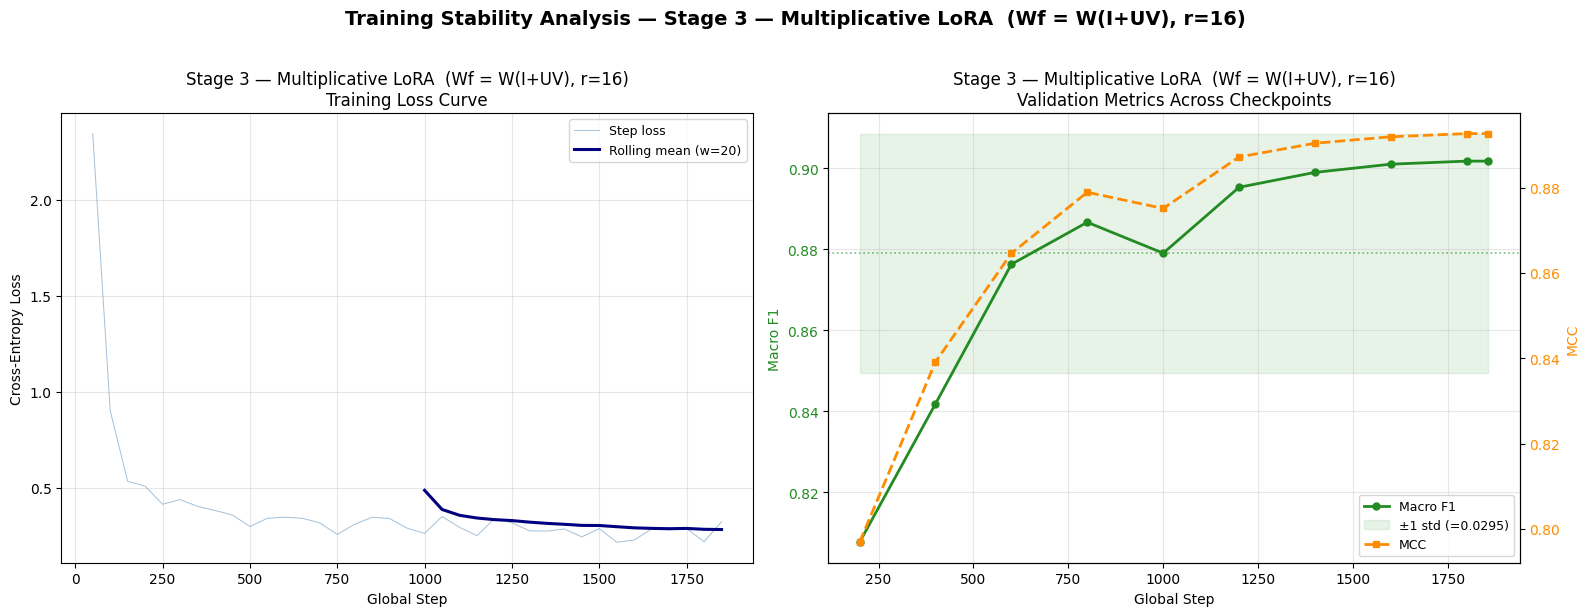

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — MultiplicativeLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9029
  Macro F1          : 0.8918  ← PRIMARY METRIC
  Weighted F1       : 0.9035
  Balanced Accuracy : 0.8920
  MCC               : 0.8831  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7263    0.7584    0.7420      1424
             gender     0.9085    0.8831    0.8956      1788
           religion     0.9594    0.9589    0.9591      1971
          ethnicity     0.9818    0.9840    0.9829      1812
                age     0.9813    0.9687    0.9750      1950
other_cyberbullying     0.7934    0.7986    0.7960      1385

           accuracy                         0.9029     10330
          macro avg     0.8918    0.8920    0.8

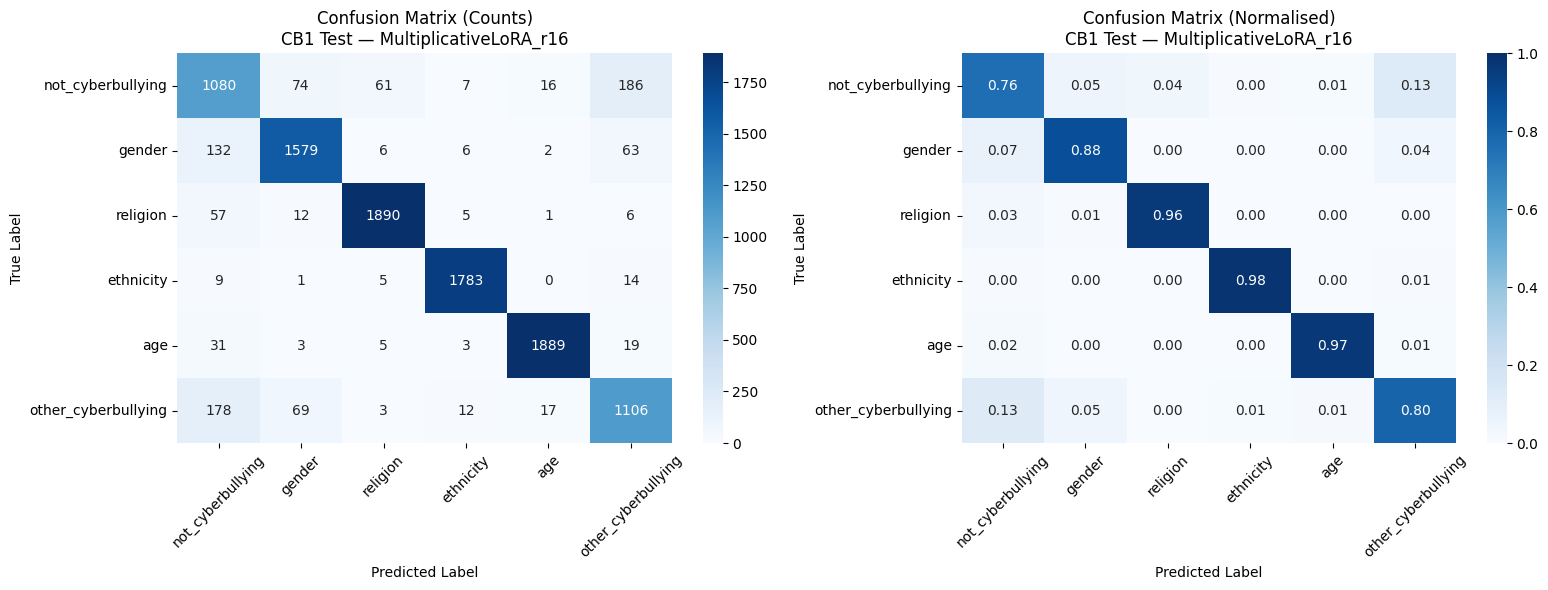


✓ Results saved → /content/drive/MyDrive/Results/CB1_MultiplicativeLoRA_Llama3B/MultiplicativeLoRA_r16/results_MultiplicativeLoRA_r16.csv

═════════════════════════════════════════════════════════════════
  STAGE 3 RESULTS — Multiplicative LoRA (r=16)
  Formula : Wf = W(I + UV)
  Model   : meta-llama/Llama-3.2-3B-Instruct
═════════════════════════════════════════════════════════════════
  Macro F1           : 0.8918   ← PRIMARY METRIC
  MCC                : 0.8831
  Accuracy           : 0.9029
  Balanced Accuracy  : 0.8920
  Trainable params   : 20,203,520
  Eff. rank (Wf)     : 2030.39   ← Stage 2 was 2030.73
  Eff. rank (UV)     : 16.00   (adapter only, reference)
  Stability score    : 0.457416
  Training time      : 2153s (0.60 hrs)
═════════════════════════════════════════════════════════════════

  Stage 2 Llama-3B r=16 reference: F1=0.8938 | MCC=0.8851 | Eff.Rank=2030.73
  → results_r16 stored. Step 13 sweeps r ∈ {4, 8, 32} and merges this result.


In [11]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 12: Multiplicative LoRA CB1 — Llama-3.2-3B — r=16 (default)
# ════════════════════════════════════════════════════════════════════════════

results_r16 = run_multiplicative_lora(
    train_df  = train_df,
    val_df    = val_df,
    test_df   = test_df,
    lora_rank = 16,
    run_label = 'MultiplicativeLoRA_r16'
)

print('\n' + '═'*65)
print('  STAGE 3 RESULTS — Multiplicative LoRA (r=16)')
print('  Formula : Wf = W(I + UV)')
print('  Model   : meta-llama/Llama-3.2-3B-Instruct')
print('═'*65)
print(f'  Macro F1           : {results_r16["macro_f1"]:.4f}   ← PRIMARY METRIC')
print(f'  MCC                : {results_r16["mcc"]:.4f}')
print(f'  Accuracy           : {results_r16["accuracy"]:.4f}')
print(f'  Balanced Accuracy  : {results_r16["balanced_accuracy"]:.4f}')
print(f'  Trainable params   : {results_r16["trainable_params"]:,}')
print(f'  Eff. rank (Wf)     : {results_r16["avg_eff_rank_Wf"]:.2f}   ← Stage 2 was 2030.73')
print(f'  Eff. rank (UV)     : {results_r16["avg_eff_rank_UV"]:.2f}   (adapter only, reference)')
print(f'  Stability score    : {results_r16["stability_score"]}')
print(f'  Training time      : {results_r16["train_runtime_s"]:.0f}s ({results_r16["train_runtime_s"]/3600:.2f} hrs)')
print('═'*65)
print()
print('  Stage 2 Llama-3B r=16 reference: F1=0.8938 | MCC=0.8851 | Eff.Rank=2030.73')
print('  → results_r16 stored. Step 13 sweeps r ∈ {4, 8, 32} and merges this result.')


---
## Step 13: Rank Sweep Ablation — r ∈ {4, 8, 32}

**Purpose**: Run Multiplicative LoRA for r ∈ {4, 8, 32}. **r=16 is merged from Step 12 — NOT re-trained.**

After the sweep, the complete 4-rank summary table is printed and saved.

**Research question answered here**: Is `eff_rank(Wf)` constant across all 4 ranks?  
- If constant → Proposition 1/3 validated for multiplicative LoRA (same as Stage 2 finding)  
- If varies → multiplicative adaptation moves I+UV away from invertibility → novel finding

**Trend to watch for Llama-3B**: Stage 2 showed monotonically increasing F1 with rank (r=4: 0.8881 → r=32: 0.8958). Does multiplicative adaptation preserve this trend?



───────────────────────────────────────────────────────
  Rank sweep: r=4
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 3 — MULTIPLICATIVE LoRA  |  MultiplicativeLoRA_r4
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 4  |  Alpha: 4  |  Scaling: 1.0
  Formula : Wf = W(I + UV)   [L2 = 0]
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 128,000
[2] Mapping labels and preparing HF datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

[4] Registering PEFT shell + injecting multiplicative adapter...
   PEFT shell registered. Model is now _is_peft_model=True.
  Replaced 112 PEFT LoraLayers → MultiplicativeLoRALayer (rank=4, alpha=4)
  Trainable: 5,064,704 / 1,808,546,816  (0.280%)
Class weights (inverse-frequency, normalised):
  [0] not_cyberbullying         1.0000
  [1] gender                    1.0000
  [2] religion                  1.0000
  [3] ethnicity                 1.0000
  [4] age                       1.0000
  [5] other_cyberbullying       1.0000
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.510295,0.439930,0.841563,0.825582,0.809843
400,0.394506,0.426805,0.858225,0.834502,0.831312
600,0.351692,0.344896,0.875795,0.864740,0.851840
800,0.304458,0.327009,0.892457,0.879204,0.871221
1000,0.269210,0.313010,0.894274,0.880351,0.874773
1200,0.344037,0.285665,0.901242,0.890223,0.881203
1400,0.299270,0.272247,0.902151,0.891745,0.882319
1600,0.243484,0.266958,0.902151,0.891832,0.882326
1800,0.242040,0.265162,0.903968,0.893886,0.884521
1857,0.335701,0.265268,0.904877,0.894886,0.885613


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

Training time: 2165s (0.60 hrs)

[5] Computing effective rank of Wf = W(I + UV)...
   avg_eff_rank(Wf)  = 2030.56  ← compare to Stage 2: 2030.73
   avg_eff_rank(UV)  = 4.00  (adapter only, reference)
   LoRA layers       = 112

[6] Generating stability report...
   Loss CV (overall)   : 0.9165180267400908
   Loss std (overall)  : 0.3769201570285956
   Val F1 std          : 0.024042465891710597
   Val MCC std         : 0.024800745587358362
   Composite score     : 0.47028
   Interpretation      : 🔴  Unstable (score ≥ 0.15) — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_MultiplicativeLoRA_Llama3B/MultiplicativeLoRA_r4/stability_curves.png


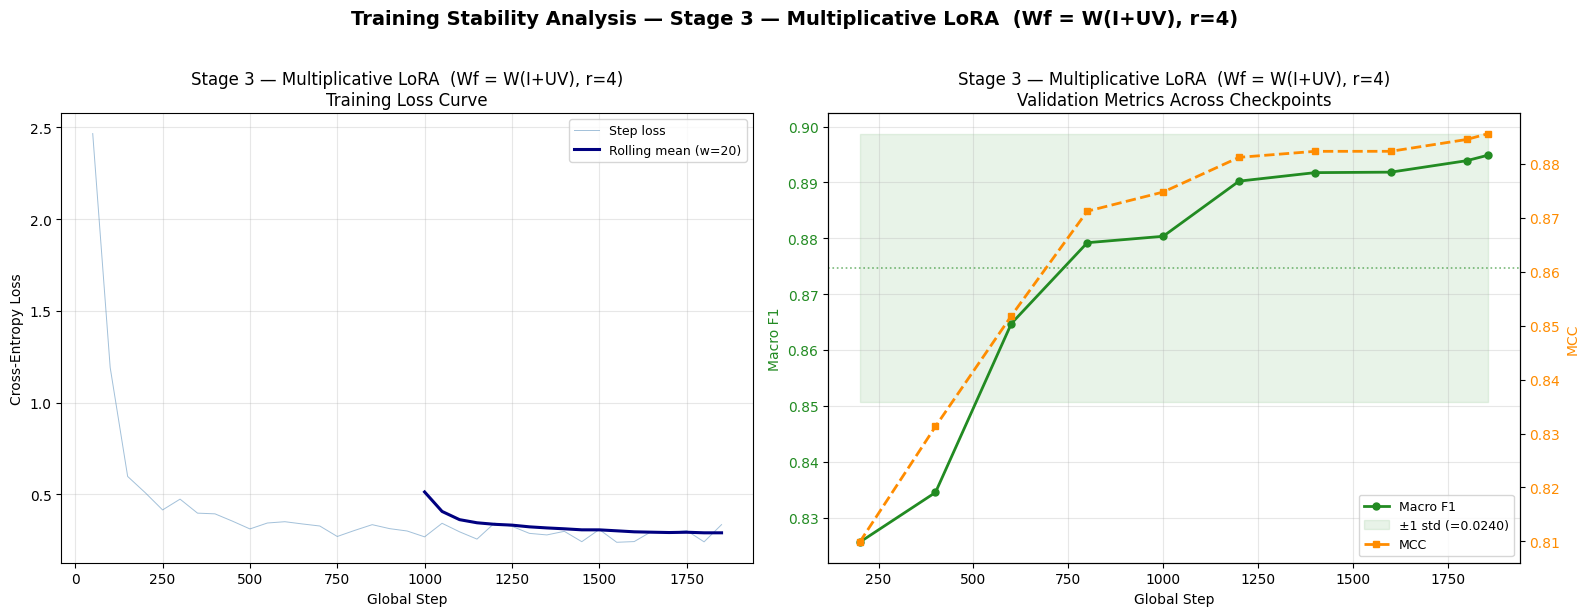

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — MultiplicativeLoRA_r4
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9005
  Macro F1          : 0.8887  ← PRIMARY METRIC
  Weighted F1       : 0.9009
  Balanced Accuracy : 0.8891
  MCC               : 0.8802  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7291    0.7353    0.7322      1424
             gender     0.9097    0.8842    0.8968      1788
           religion     0.9585    0.9599    0.9592      1971
          ethnicity     0.9737    0.9812    0.9775      1812
                age     0.9818    0.9687    0.9752      1950
other_cyberbullying     0.7786    0.8051    0.7916      1385

           accuracy                         0.9005     10330
          macro avg     0.8886    0.8891    0.88

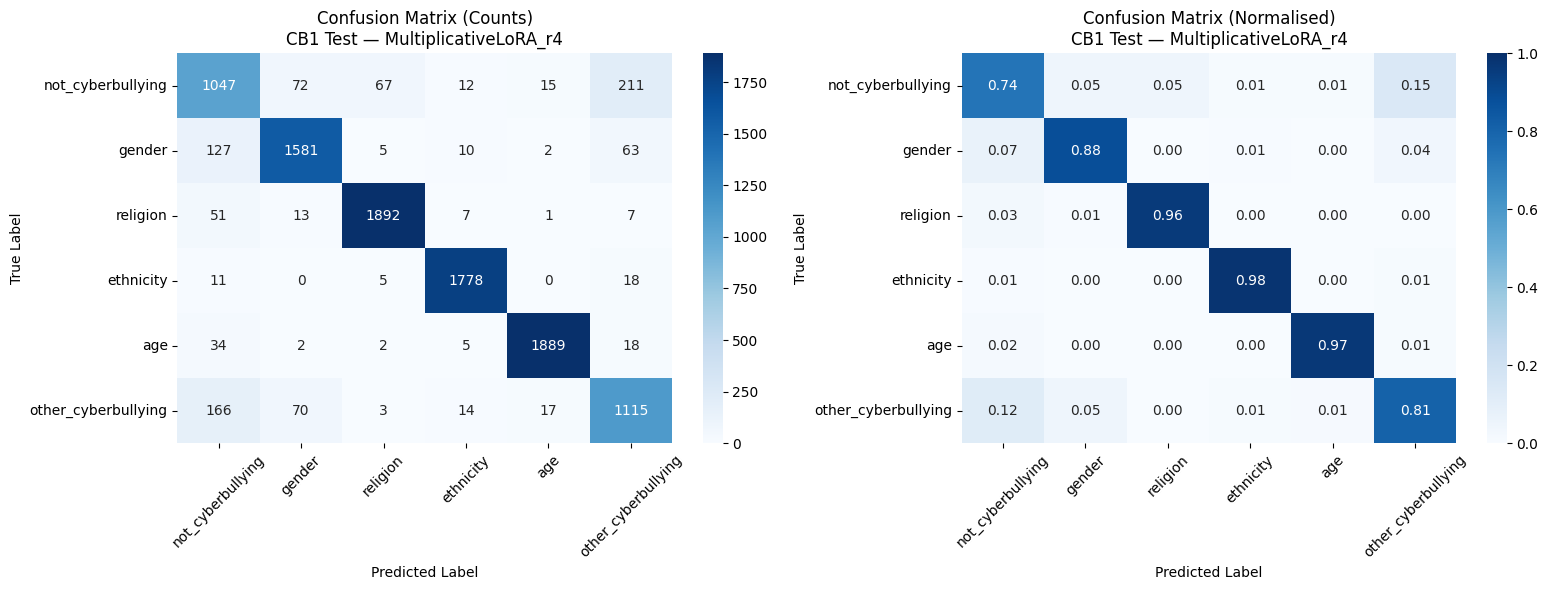


✓ Results saved → /content/drive/MyDrive/Results/CB1_MultiplicativeLoRA_Llama3B/MultiplicativeLoRA_r4/results_MultiplicativeLoRA_r4.csv

───────────────────────────────────────────────────────
  Rank sweep: r=8
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 3 — MULTIPLICATIVE LoRA  |  MultiplicativeLoRA_r8
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 8  |  Alpha: 8  |  Scaling: 1.0
  Formula : Wf = W(I + UV)   [L2 = 0]
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 128,000
[2] Mapping labels and preparing HF datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

[4] Registering PEFT shell + injecting multiplicative adapter...
   PEFT shell registered. Model is now _is_peft_model=True.
  Replaced 112 PEFT LoraLayers → MultiplicativeLoRALayer (rank=8, alpha=8)
  Trainable: 10,110,976 / 1,813,593,088  (0.558%)
Class weights (inverse-frequency, normalised):
  [0] not_cyberbullying         1.0000
  [1] gender                    1.0000
  [2] religion                  1.0000
  [3] ethnicity                 1.0000
  [4] age                       1.0000
  [5] other_cyberbullying       1.0000
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.513602,0.431194,0.838231,0.821904,0.807444
400,0.406612,0.403300,0.865798,0.845365,0.839978
600,0.345626,0.346221,0.874281,0.863504,0.849425
800,0.302553,0.328804,0.895183,0.883477,0.874177
1000,0.265509,0.321101,0.893972,0.879881,0.874645
1200,0.337189,0.283593,0.899424,0.888999,0.879078
1400,0.293362,0.268089,0.901848,0.891691,0.882041
1600,0.234302,0.265629,0.902454,0.892931,0.882839
1800,0.229368,0.262712,0.903968,0.894446,0.884648
1857,0.333876,0.262532,0.904271,0.894689,0.885003


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

Training time: 2149s (0.60 hrs)

[5] Computing effective rank of Wf = W(I + UV)...
   avg_eff_rank(Wf)  = 2030.57  ← compare to Stage 2: 2030.73
   avg_eff_rank(UV)  = 8.00  (adapter only, reference)
   LoRA layers       = 112

[6] Generating stability report...
   Loss CV (overall)   : 0.8982713596691743
   Loss std (overall)  : 0.3613676008714725
   Val F1 std          : 0.02341442624828112
   Val MCC std         : 0.024378169231517925
   Composite score     : 0.460843
   Interpretation      : 🔴  Unstable (score ≥ 0.15) — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_MultiplicativeLoRA_Llama3B/MultiplicativeLoRA_r8/stability_curves.png


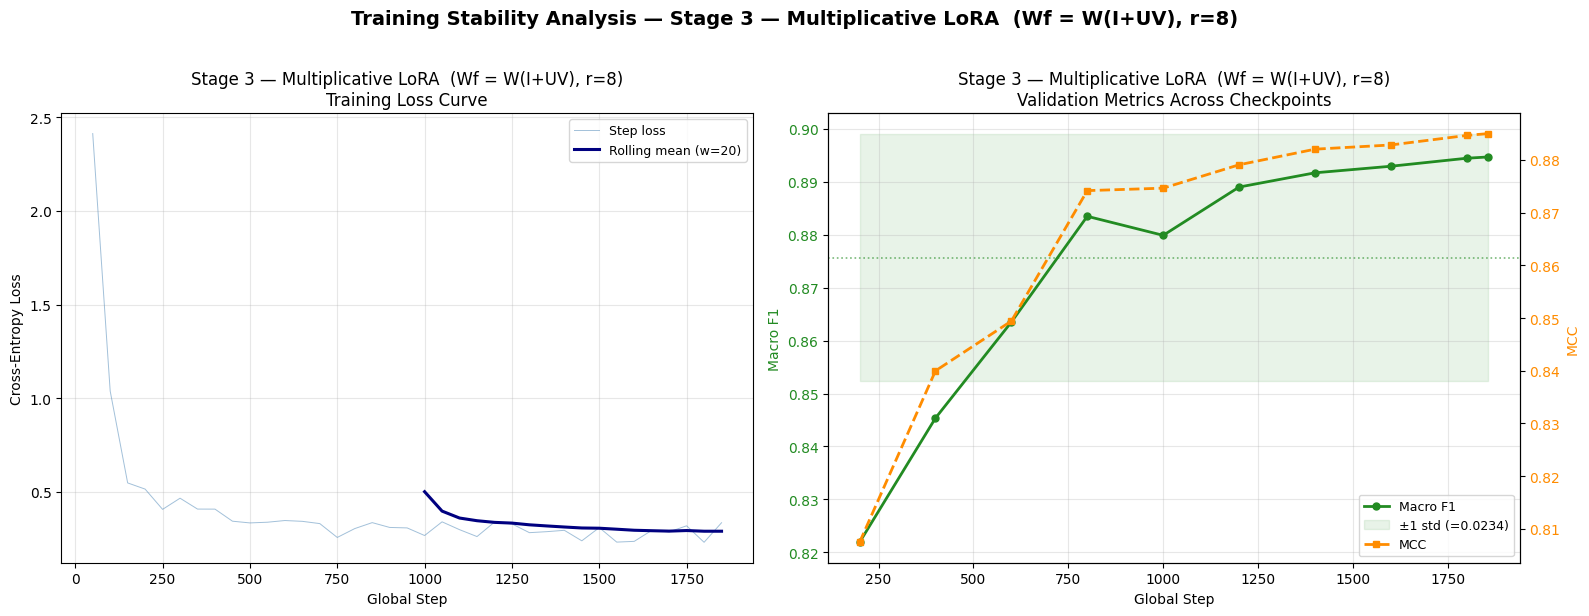

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — MultiplicativeLoRA_r8
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9016
  Macro F1          : 0.8901  ← PRIMARY METRIC
  Weighted F1       : 0.9021
  Balanced Accuracy : 0.8904
  MCC               : 0.8816  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7231    0.7444    0.7336      1424
             gender     0.9126    0.8814    0.8967      1788
           religion     0.9590    0.9614    0.9602      1971
          ethnicity     0.9764    0.9818    0.9791      1812
                age     0.9808    0.9703    0.9755      1950
other_cyberbullying     0.7887    0.8029    0.7957      1385

           accuracy                         0.9016     10330
          macro avg     0.8901    0.8904    0.89

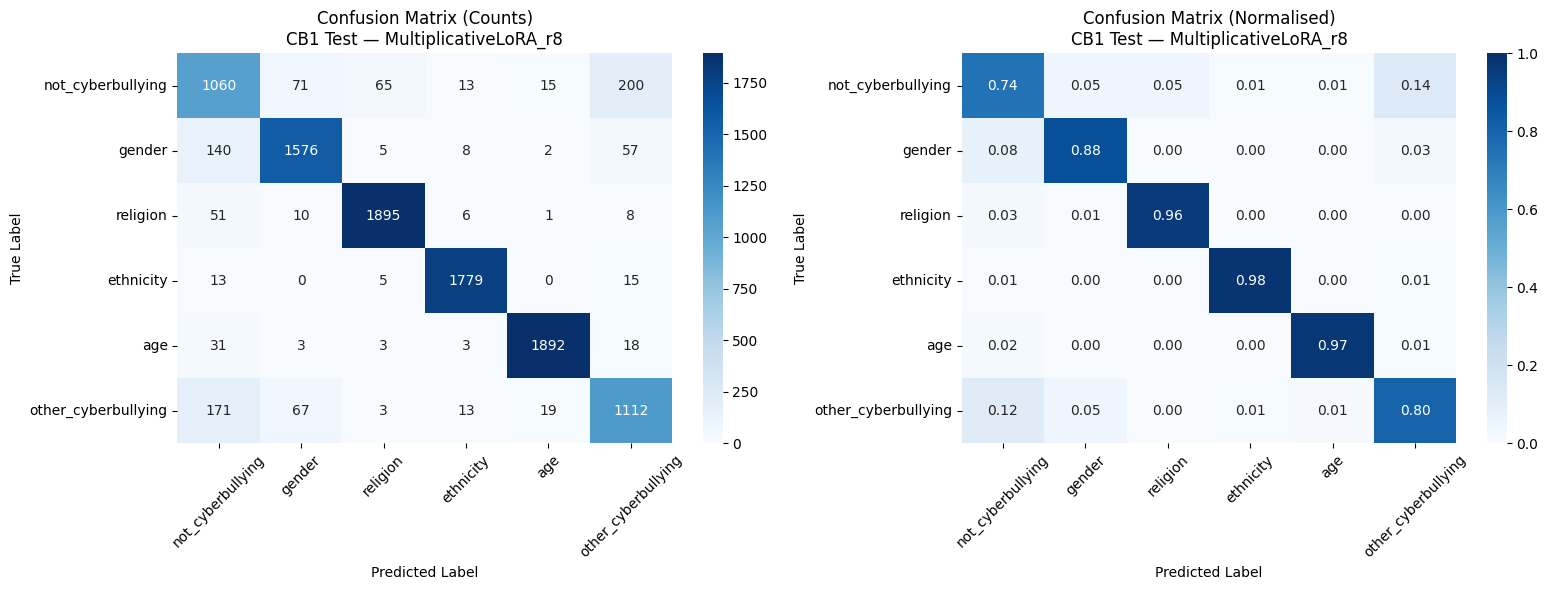


✓ Results saved → /content/drive/MyDrive/Results/CB1_MultiplicativeLoRA_Llama3B/MultiplicativeLoRA_r8/results_MultiplicativeLoRA_r8.csv

───────────────────────────────────────────────────────
  Rank sweep: r=32
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 3 — MULTIPLICATIVE LoRA  |  MultiplicativeLoRA_r32
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 32  |  Alpha: 32  |  Scaling: 1.0
  Formula : Wf = W(I + UV)   [L2 = 0]
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 128,000
[2] Mapping labels and preparing HF datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

[4] Registering PEFT shell + injecting multiplicative adapter...
   PEFT shell registered. Model is now _is_peft_model=True.
  Replaced 112 PEFT LoraLayers → MultiplicativeLoRALayer (rank=32, alpha=32)
  Trainable: 40,388,608 / 1,843,870,720  (2.190%)
Class weights (inverse-frequency, normalised):
  [0] not_cyberbullying         1.0000
  [1] gender                    1.0000
  [2] religion                  1.0000
  [3] ethnicity                 1.0000
  [4] age                       1.0000
  [5] other_cyberbullying       1.0000
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.520997,0.531469,0.815510,0.793868,0.781034
400,0.400677,0.465032,0.862163,0.838826,0.837959
600,0.337290,0.336645,0.887913,0.876376,0.865697
800,0.313521,0.328096,0.896092,0.882580,0.875694
1000,0.266475,0.308887,0.897304,0.883162,0.878211
1200,0.338800,0.263064,0.907301,0.895647,0.888523
1400,0.273631,0.248365,0.910936,0.902084,0.893104
1600,0.227862,0.245619,0.914874,0.905945,0.897663
1800,0.222633,0.241865,0.915480,0.906602,0.898391
1857,0.308871,0.241858,0.915480,0.906602,0.898391


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

Training time: 2150s (0.60 hrs)

[5] Computing effective rank of Wf = W(I + UV)...
   avg_eff_rank(Wf)  = 2030.17  ← compare to Stage 2: 2030.73
   avg_eff_rank(UV)  = 32.00  (adapter only, reference)
   LoRA layers       = 112

[6] Generating stability report...
   Loss CV (overall)   : 0.8409882053726617
   Loss std (overall)  : 0.32572261875440833
   Val F1 std          : 0.03458010842312476
   Val MCC std         : 0.035060910517579334
   Composite score     : 0.437784
   Interpretation      : 🔴  Unstable (score ≥ 0.15) — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_MultiplicativeLoRA_Llama3B/MultiplicativeLoRA_r32/stability_curves.png


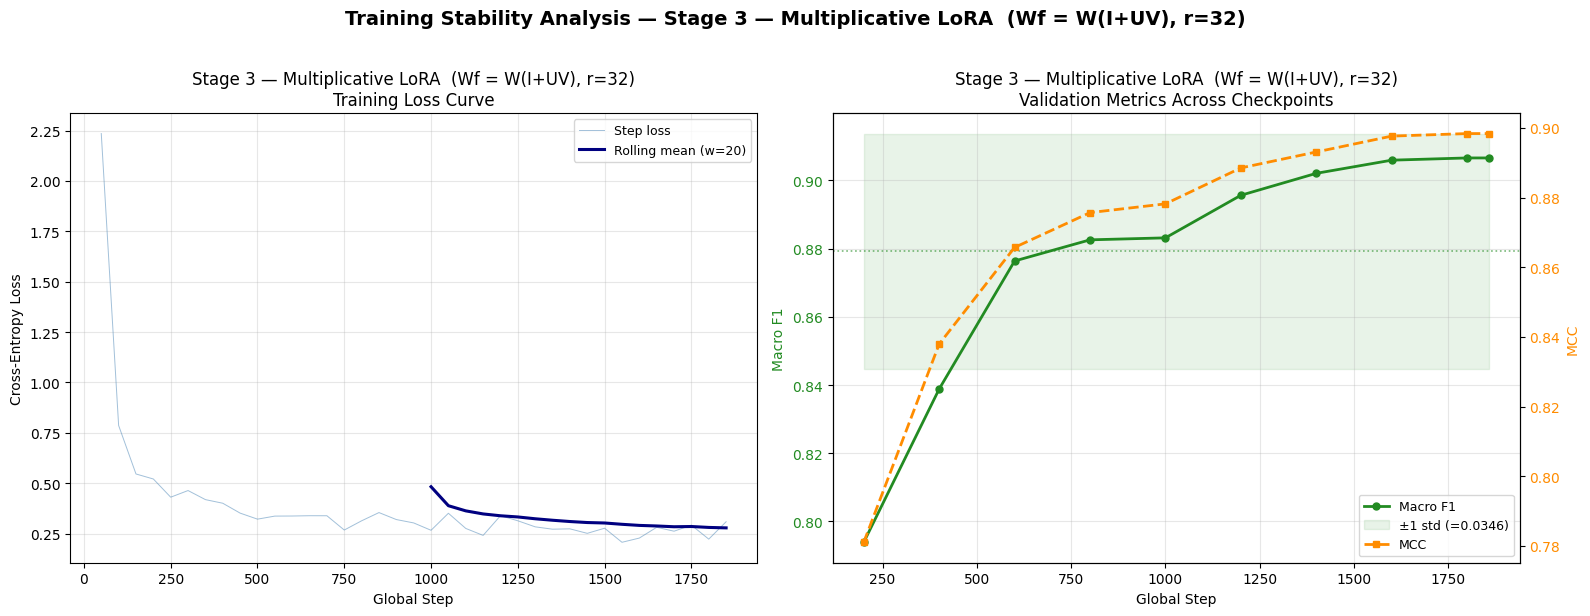

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — MultiplicativeLoRA_r32
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9050
  Macro F1          : 0.8939  ← PRIMARY METRIC
  Weighted F1       : 0.9053
  Balanced Accuracy : 0.8940
  MCC               : 0.8857  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7372    0.7507    0.7439      1424
             gender     0.9066    0.8904    0.8984      1788
           religion     0.9600    0.9609    0.9604      1971
          ethnicity     0.9775    0.9851    0.9813      1812
                age     0.9823    0.9692    0.9757      1950
other_cyberbullying     0.7987    0.8079    0.8033      1385

           accuracy                         0.9050     10330
          macro avg     0.8937    0.8940    0.8

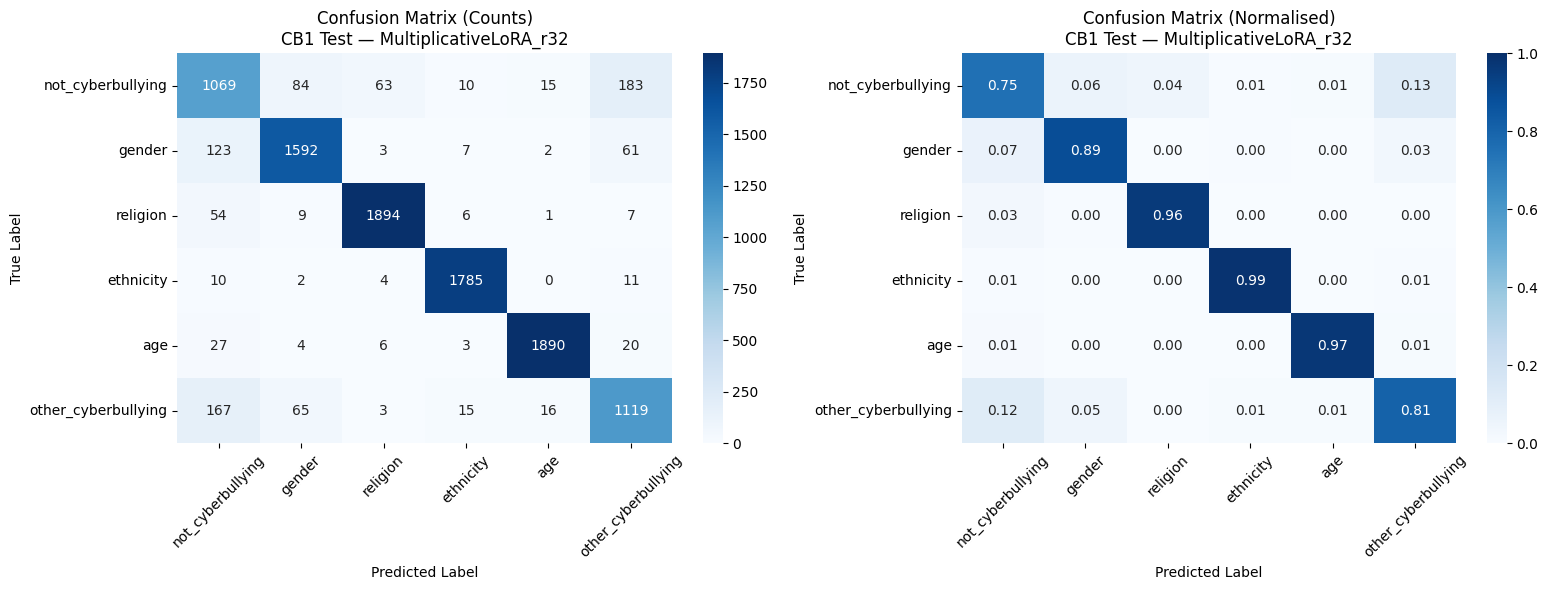


✓ Results saved → /content/drive/MyDrive/Results/CB1_MultiplicativeLoRA_Llama3B/MultiplicativeLoRA_r32/results_MultiplicativeLoRA_r32.csv

════════════════════════════════════════════════════════════════════════════════
STAGE 3a CB1 LLAMA-3B — 4-RANK SUMMARY TABLE
Formula: Wf = W(I + UV)  |  Wf = W + W@(UV)
════════════════════════════════════════════════════════════════════════════════
   r |    Trainable |  Macro F1 |     MCC |  Eff.Rank Wf |  Eff.Rank UV |  Time(h) | Trend
─────────────────────────────────────────────────────────────────────────────────────
   4 |    5,064,704 |    0.8887 |  0.8802 |      2030.56 |         4.00 |     0.60 | 
   8 |   10,110,976 |    0.8901 |  0.8816 |      2030.57 |         8.00 |     0.60 | ↑
  16 |   20,203,520 |    0.8918 |  0.8831 |      2030.39 |        16.00 |     0.60 | ↑
  32 |   40,388,608 |    0.8939 |  0.8857 |      2030.17 |        32.00 |     0.60 | ↑ ★

  Stage 2 reference (Llama-3B Standard LoRA):
  r=4: F1=0.8881 | r=8: F1=0.8902 | 

In [12]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 13: Rank Sweep — r ∈ {4, 8, 32}
# r=16 NOT repeated — merged from Step 12 results_r16
# ════════════════════════════════════════════════════════════════════════════

all_rank_results = {}
all_rank_results[16] = results_r16   # Merge r=16 from Step 12

for rank in RANK_SWEEP:   # [4, 8, 32]
    print(f'\n{"─"*55}')
    print(f'  Rank sweep: r={rank}')
    print(f'{"─"*55}')
    result = run_multiplicative_lora(
        train_df  = train_df,
        val_df    = val_df,
        test_df   = test_df,
        lora_rank = rank,
        run_label = f'MultiplicativeLoRA_r{rank}'
    )
    all_rank_results[rank] = result

# ── 4-rank summary table ──────────────────────────────────────────────────────
print(f'\n{"═"*80}')
print('STAGE 3a CB1 LLAMA-3B — 4-RANK SUMMARY TABLE')
print('Formula: Wf = W(I + UV)  |  Wf = W + W@(UV)')
print(f'{"═"*80}')
print(f'{"r":>4} | {"Trainable":>12} | {"Macro F1":>9} | {"MCC":>7} | '
      f'{"Eff.Rank Wf":>12} | {"Eff.Rank UV":>12} | {"Time(h)":>8} | Trend')
print(f'{"─"*85}')

sorted_ranks = sorted(all_rank_results.keys())
prev_f1 = None
for r in sorted_ranks:
    res  = all_rank_results[r]
    trend = ''
    if prev_f1 is not None:
        trend = '↑' if res['macro_f1'] > prev_f1 else ('↓' if res['macro_f1'] < prev_f1 else '→')
    best_mark = ' ★' if res['macro_f1'] == max(v['macro_f1'] for v in all_rank_results.values()) else ''
    print(
        f'{r:>4} | {res["trainable_params"]:>12,} | '
        f'{res["macro_f1"]:>9.4f} | {res["mcc"]:>7.4f} | '
        f'{res["avg_eff_rank_Wf"]:>12.2f} | {res["avg_eff_rank_UV"]:>12.2f} | '
        f'{res["train_runtime_s"]/3600:>8.2f} | {trend}{best_mark}'
    )
    prev_f1 = res['macro_f1']

print(f'\n  Stage 2 reference (Llama-3B Standard LoRA):')
print(f'  r=4: F1=0.8881 | r=8: F1=0.8902 | r=16: F1=0.8938 | r=32: F1=0.8958 (best)')
print(f'  Eff.Rank Wf: 2030.71–2030.76 (constant across all r — Proposition 1 confirmed)')

# ── Eff. rank constancy analysis ──────────────────────────────────────────────
print(f'\n{"═"*50}')
print('EFFECTIVE RANK CONSTANCY ANALYSIS')
print(f'{"═"*50}')
eff_ranks = [all_rank_results[r]['avg_eff_rank_Wf'] for r in sorted_ranks]
eff_range = max(eff_ranks) - min(eff_ranks)
print(f'Eff. rank values: {[f"{v:.2f}" for v in eff_ranks]}')
print(f'Range: {eff_range:.2f}')
if eff_range < 1.0:
    print('✓ CONSTANT — Proposition 1/3 validated for Multiplicative LoRA.')
    print('  I+UV remains near-invertible across all ranks.')
else:
    print('⚠ VARIES — Multiplicative adaptation affects rank dynamics.')
    print('  Document and explain in paper — this is a novel finding.')

# ── Save final CSV ─────────────────────────────────────────────────────────────
summary_rows = []
for r in sorted_ranks:
    res = all_rank_results[r]
    summary_rows.append({
        'model': 'Llama-3.2-3B', 'stage': '3a', 'formula': 'Wf=W(I+UV)',
        'dataset': 'CB1', 'rank': r,
        'trainable_params': res['trainable_params'],
        'macro_f1': res['macro_f1'], 'mcc': res['mcc'],
        'accuracy': res['accuracy'], 'balanced_accuracy': res['balanced_accuracy'],
        'avg_eff_rank_Wf': res['avg_eff_rank_Wf'],
        'avg_eff_rank_UV': res['avg_eff_rank_UV'],
        'stability_score': res['stability_score'],
        'train_runtime_s': res['train_runtime_s'],
    })

summary_df   = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUTPUT_DIR, 'stage3a_cb1_llama3b_rank_sweep_FINAL.csv')
summary_df.to_csv(summary_path, index=False)
print(f'\n✓ Final rank sweep results saved → {summary_path}')


---
## Step 14: Cross-Stage Stability Comparison (Run After All Stages Complete)

**Purpose**: Compare training stability across Stages 2, 3, and 4 in a single figure.  
**When to run**: After Stage 3 and Stage 4 notebooks have completed.  
**Identical to Stage 2** — template is filled in after all stages are done.

Stage 2 stability (r=16): loss_cv=0.825 | loss_std=0.343 | val_f1_std=0.0247 | score=0.4249


In [13]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 14A: CROSS-STAGE STABILITY COMPARISON
# Uncomment and fill in after Stage 3 and Stage 4 notebooks complete
# ════════════════════════════════════════════════════════════════════════════

# --- TEMPLATE: fill in results_s3 and results_s4 after those stages ---
# plot_cross_stage_stability(
#     stage_reports={
#         'Stage 2\nWf = W + AB':        <paste Stage 2 stability_report here>,
#         'Stage 3\nWf = W(I+UV)':       results_r16['stability_report'],
#         'Stage 4\nWf = W(I+UV)+AB':    <paste Stage 4 stability_report here>,
#     },
#     save_path=os.path.join(OUTPUT_DIR, 'cross_stage_stability.png')
# )

# ── Stage 3 only — available now ─────────────────────────────────────────────
print('Stage 3 stability report (r=16):')
rep = results_r16['stability_cb'].get_stability_report()
print(f'  loss_cv_overall  : {rep.get("loss_cv_overall",  "N/A")}')
print(f'  loss_std_overall : {rep.get("loss_std_overall", "N/A")}')
print(f'  val_f1_std       : {rep.get("val_f1_std",       "N/A")}')
print(f'  val_mcc_std      : {rep.get("val_mcc_std",      "N/A")}')
print(f'  stability_score  : {rep.get("stability_score",  "N/A")}')

# ════════════════════════════════════════════════════════════════════════════
# STEP 14B: FINAL STAGE 3 SUMMARY
# ════════════════════════════════════════════════════════════════════════════
print('\n' + '═'*70)
print('  STAGE 3a COMPLETE — MULTIPLICATIVE LoRA')
print('  Formula  : Wf = W(I + UV)')
print('  Model    : meta-llama/Llama-3.2-3B-Instruct')
print('  Dataset  : CB1 — 6-Class Cyberbullying Detection')
print('  Split    : 75/25 stratified (protocol-compliant)')
print('═'*70)

best_r  = max(all_rank_results, key=lambda r: all_rank_results[r]['macro_f1'])
best_res = all_rank_results[best_r]
print(f'\n── BEST RESULT (r={best_r}) ──')
print(f'  Macro F1           : {best_res["macro_f1"]:.4f}   ← PRIMARY METRIC')
print(f'  MCC                : {best_res["mcc"]:.4f}')
print(f'  Accuracy           : {best_res["accuracy"]:.4f}')
print(f'  Balanced Accuracy  : {best_res["balanced_accuracy"]:.4f}')
print(f'  Trainable params   : {best_res["trainable_params"]:,}')
print(f'  Eff. rank (Wf)     : {best_res["avg_eff_rank_Wf"]:.2f}   ← compare to Stage 2: 2030.73')
print(f'  Eff. rank (UV)     : {best_res["avg_eff_rank_UV"]:.2f}')
print(f'  Training time      : {best_res["train_runtime_s"]:.0f}s ({best_res["train_runtime_s"]/3600:.2f} hrs)')
print()
print('── REFERENCES ──')
print('  Stage 2 Llama-3B best (r=32): F1=0.8958 | MCC=0.8874 | Eff.Rank=2030.76')
print('  Stage 2 best overall (Gemma-2-9B r=32): F1=0.9010 | MCC=0.8936')
print('  Stage 1 ceiling (Phi-4 FS)  : F1=0.5757 | MCC=0.5614')
print()
print('  → Pass results_r16[\'stability_cb\'] to plot_cross_stage_stability() after Stage 4 completes.')


Stage 3 stability report (r=16):
  loss_cv_overall  : 0.8852928592215558
  loss_std_overall : 0.34620629448242835
  val_f1_std       : 0.029538375057606814
  val_mcc_std      : 0.02939973459905556
  stability_score  : 0.457416

══════════════════════════════════════════════════════════════════════
  STAGE 3a COMPLETE — MULTIPLICATIVE LoRA
  Formula  : Wf = W(I + UV)
  Model    : meta-llama/Llama-3.2-3B-Instruct
  Dataset  : CB1 — 6-Class Cyberbullying Detection
  Split    : 75/25 stratified (protocol-compliant)
══════════════════════════════════════════════════════════════════════

── BEST RESULT (r=32) ──
  Macro F1           : 0.8939   ← PRIMARY METRIC
  MCC                : 0.8857
  Accuracy           : 0.9050
  Balanced Accuracy  : 0.8940
  Trainable params   : 40,388,608
  Eff. rank (Wf)     : 2030.17   ← compare to Stage 2: 2030.73
  Eff. rank (UV)     : 32.00
  Training time      : 2150s (0.60 hrs)

── REFERENCES ──
  Stage 2 Llama-3B best (r=32): F1=0.8958 | MCC=0.8874 | Eff.Ra